# Wing Skin MDO

Spanwise wing-skin sizing across two laminate families using `optimize_wing()`.

**Two families compared:**
- Family A: `[0/+/-45/90]s` -- standard quasi-isotropic (discrete angles)
- Family B: `[0/theta/-theta/90]s` -- continuous theta optimisation

**What this shows:**
- How the spanwise load distribution drives thickness variation root-to-tip
- How freeing the ply angle as a continuous variable reduces mass vs a fixed quasi-isotropic stack
- Which ply in the half-stack is governing at each span station (heatmap)

In [13]:
import sys, os
from pathlib import Path

_nb_dir = Path(os.path.abspath('')).resolve()
_repo_root = _nb_dir.parent if _nb_dir.name == 'notebooks' else _nb_dir
sys.path.insert(0, str(_repo_root / 'src'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from composite_panel import IM7_8552, WingGeometry
from composite_panel.optimizer import optimize_wing, detect_balance_pairs

print('Setup complete.')

Setup complete.


---
## 1. Wing Geometry and Flight Condition

Supersonic transport concept: large swept delta with high aspect ratio for range.
Loads at Mach 1.6 cruise, 15 km, 4 deg AoA, 2.5g limit manoeuvre (FAR 25.337).

In [14]:
mach      = 1.6
alt_m     = 15_000
alpha_deg = 4.0
n_load    = 2.5       # limit load factor (FAR 25.337)
mat       = IM7_8552()

wing = WingGeometry(
    semi_span    = 4.5,
    root_chord   = 4.0,
    taper_ratio  = 0.25,
    sweep_le_deg = 50.0,
    t_over_c     = 0.04,
    mtow_n       = 120_000.0,
)

print(f'Wing: b/2={wing.semi_span}m  c_root={wing.root_chord}m  '
      f'lambda={wing.taper_ratio}  sweep={wing.sweep_le_deg}deg')
print(f'Flight: Mach {mach} @ {alt_m/1e3:.0f} km  alpha={alpha_deg}deg  n={n_load}g')
print(f'Material: {mat.name}')

Wing: b/2=4.5m  c_root=4.0m  lambda=0.25  sweep=50.0deg
Flight: Mach 1.6 @ 15 km  alpha=4.0deg  n=2.5g
Material: IM7/8552


---
## 2. Spanwise Sizing

`optimize_wing()` steps through `n_stations` eta locations, runs `optimize_laminate()` at each,
and collects thicknesses, RFs, and ply maps.

In [15]:
# Family A: [0/+/-45/90]s  --  standard aerospace quasi-isotropic
fam_a   = [0.0, 45.0, -45.0, 90.0]
pairs_a = detect_balance_pairs(fam_a)

# Family B: [0/theta/-theta/90]s with continuous theta optimisation
fam_b_init  = [0.0, 45.0, -45.0, 90.0]
pairs_b     = [(1, 2)]
bounds_b    = [(0.0, 0.0), (5.0, 85.0), (-85.0, -5.0), (90.0, 90.0)]

print('Family A  [0/+/-45/90]s  --  spanwise sizing ...')
wing_a = optimize_wing(
    wing=wing, mach=mach, altitude_m=alt_m, alpha_deg=alpha_deg,
    mat=mat, angles_half_deg=fam_a,
    n_load=n_load, n_stations=12, rf_min=1.5, t_min=0.05e-3, t_init=0.15e-3,
    balance_pairs=pairs_a,
)

print('Family B  [0/theta/-theta/90]s continuous  --  spanwise sizing ...')
wing_b = optimize_wing(
    wing=wing, mach=mach, altitude_m=alt_m, alpha_deg=alpha_deg,
    mat=mat, angles_half_deg=fam_b_init,
    n_load=n_load, n_stations=12, rf_min=1.5, t_min=0.05e-3, t_init=0.15e-3,
    balance_pairs=pairs_b, optimize_angles=True, angle_bounds_deg=bounds_b,
)

print(f'\nFamily A root/tip h: {wing_a.thicknesses[0]*1e3:.2f} / {wing_a.thicknesses[-1]*1e3:.2f} mm')
print(f'Family B root/tip h: {wing_b.thicknesses[0]*1e3:.2f} / {wing_b.thicknesses[-1]*1e3:.2f} mm')

Family A  [0/+/-45/90]s  --  spanwise sizing ...
  Sizing 12 spanwise stations  --  RF >= 1.5  t_min = 0.05 mm
  [############]  eta=0.95  h=2.91mm  RF=1.501  [OK]
  Upper-skin mass (semi-span): 110.01 kg
Family B  [0/theta/-theta/90]s continuous  --  spanwise sizing ...
  Sizing 12 spanwise stations  --  RF >= 1.5  t_min = 0.05 mm
  [############]  eta=0.95  h=2.90mm  RF=1.501  [OK]
  Upper-skin mass (semi-span): 109.79 kg

Family A root/tip h: 9.47 / 2.91 mm
Family B root/tip h: 9.45 / 2.90 mm


---
## 3. Visualisation

Figure saved -> C:\Users\AlexanderAmos\Documents\code\composite_panel\outputs\wing_skin_mdo.png


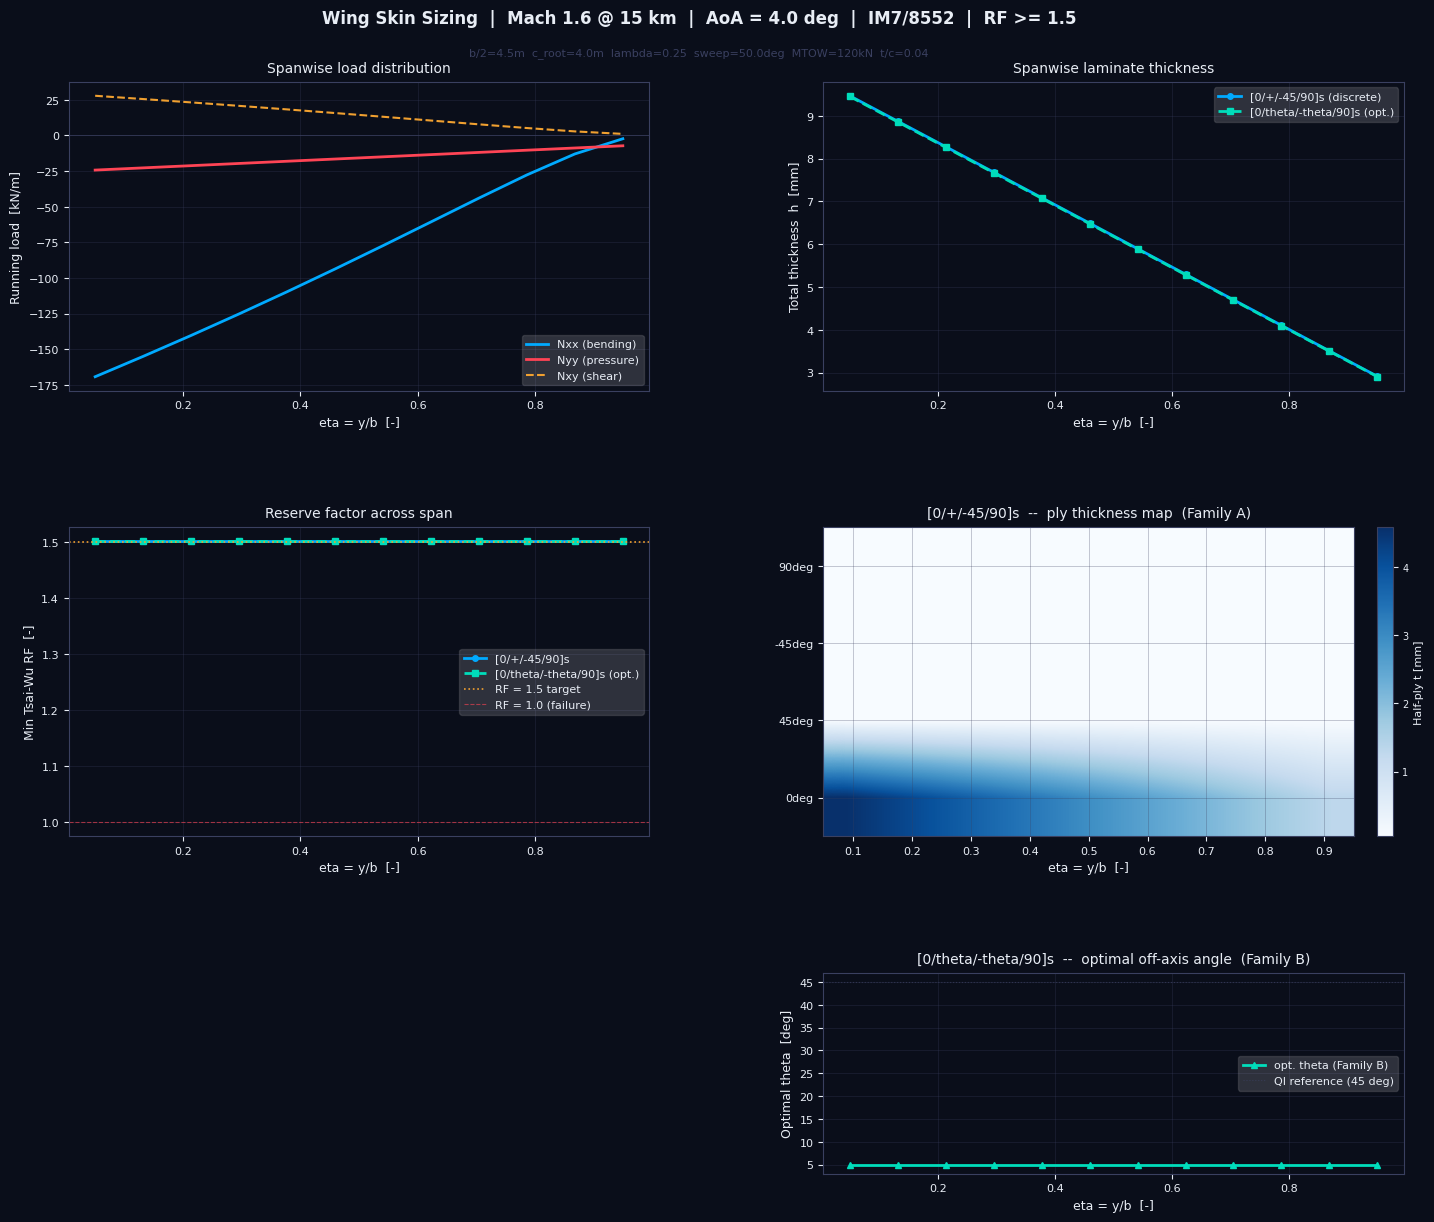

In [16]:
bg    = '#0a0e1a'; blue  = '#00aaff'; gold  = '#f0a030'
red   = '#ff4455'; dim   = '#3a4060'; white = '#e8edf5'
teal  = '#00ddbb'

def _style(ax):
    ax.set_facecolor(bg)
    ax.tick_params(colors=white, labelsize=8)
    ax.xaxis.label.set_color(white)
    ax.yaxis.label.set_color(white)
    ax.title.set_color(white)
    for spine in ax.spines.values():
        spine.set_edgecolor(dim)
    ax.grid(color=dim, linewidth=0.4, alpha=0.5)

fig = plt.figure(figsize=(15, 13), facecolor=bg)
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.30,
                        left=0.08, right=0.97, top=0.91, bottom=0.07,
                        height_ratios=[1, 1, 0.65])
etas = wing_a.etas

# --- Row 0, col 0: Load distribution ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(etas, wing_a.Nxx / 1e3, color=blue, lw=2.0, label='Nxx (bending)')
ax1.plot(etas, wing_a.Nyy / 1e3, color=red,  lw=2.0, label='Nyy (pressure)')
ax1.plot(etas, wing_a.Nxy / 1e3, color=gold, lw=1.5, linestyle='--', label='Nxy (shear)')
ax1.axhline(0, color=dim, lw=0.5)
ax1.set_xlabel('eta = y/b  [-]', fontsize=9)
ax1.set_ylabel('Running load  [kN/m]', fontsize=9)
ax1.set_title('Spanwise load distribution', fontsize=10, pad=7)
ax1.legend(fontsize=8, framealpha=0.15, labelcolor=white)
_style(ax1)

# --- Row 0, col 1: Thickness ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(etas, wing_a.thicknesses * 1e3, color=blue,
         lw=2.0, marker='o', markersize=4, label='[0/+/-45/90]s (discrete)')
ax2.plot(etas, wing_b.thicknesses * 1e3, color=teal,
         lw=2.0, marker='s', markersize=4, linestyle='--', label='[0/theta/-theta/90]s (opt.)')
ax2.set_xlabel('eta = y/b  [-]', fontsize=9)
ax2.set_ylabel('Total thickness  h  [mm]', fontsize=9)
ax2.set_title('Spanwise laminate thickness', fontsize=10, pad=7)
ax2.legend(fontsize=8, framealpha=0.15, labelcolor=white)
_style(ax2)

# --- Row 1, col 0: Reserve factors ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(etas, wing_a.min_rfs, color=blue, lw=2.0, marker='o', markersize=4,
         label='[0/+/-45/90]s')
ax3.plot(etas, wing_b.min_rfs, color=teal, lw=2.0, marker='s', markersize=4,
         linestyle='--', label='[0/theta/-theta/90]s (opt.)')
ax3.axhline(1.5, color=gold, lw=1.2, linestyle=':', label='RF = 1.5 target')
ax3.axhline(1.0, color=red,  lw=0.8, linestyle='--', alpha=0.6, label='RF = 1.0 (failure)')
ax3.set_xlabel('eta = y/b  [-]', fontsize=9)
ax3.set_ylabel('Min Tsai-Wu RF  [-]', fontsize=9)
ax3.set_title('Reserve factor across span', fontsize=10, pad=7)
ax3.legend(fontsize=8, framealpha=0.15, labelcolor=white)
_style(ax3)

# --- Row 1, col 1: Ply thickness heatmap (Family A) ---
ax4 = fig.add_subplot(gs[1, 1])
angle_labels = [f'{int(a)}deg' for a in fam_a]
t_matrix = wing_a.t_half_matrix * 1e3
im = ax4.imshow(t_matrix.T, aspect='auto',
                extent=[etas[0], etas[-1], -0.5, len(fam_a) - 0.5],
                origin='lower', cmap='Blues', interpolation='bilinear')
cbar = fig.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)
cbar.ax.tick_params(colors=white, labelsize=7)
cbar.set_label('Half-ply t [mm]', color=white, fontsize=8)
cbar.outline.set_edgecolor(dim)
ax4.set_yticks(range(len(fam_a)))
ax4.set_yticklabels(angle_labels, fontsize=8)
ax4.set_xlabel('eta = y/b  [-]', fontsize=9)
ax4.set_title('[0/+/-45/90]s  --  ply thickness map  (Family A)', fontsize=10, pad=7)
_style(ax4)

# --- Row 2, col 1: Optimal theta for Family B ---
theta_span = np.array([r.angles_half[1] for r in wing_b.opt_results])
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(etas, theta_span, color=teal, lw=2.0, marker='^', markersize=5,
         label='opt. theta (Family B)')
ax5.axhline(45, color=dim, lw=0.8, linestyle=':', alpha=0.7, label='QI reference (45 deg)')
ax5.set_xlabel('eta = y/b  [-]', fontsize=9)
ax5.set_ylabel('Optimal theta  [deg]', fontsize=9)
ax5.set_title('[0/theta/-theta/90]s  --  optimal off-axis angle  (Family B)', fontsize=10, pad=7)
ax5.legend(fontsize=8, framealpha=0.15, labelcolor=white)
_style(ax5)

# Leave row 2, col 0 empty (or add a text note)
ax_empty = fig.add_subplot(gs[2, 0])
ax_empty.set_visible(False)

fig.text(0.5, 0.955,
         f'Wing Skin Sizing  |  Mach {mach} @ {alt_m/1e3:.0f} km  '
         f'|  AoA = {alpha_deg} deg  |  {mat.name}  |  RF >= 1.5',
         ha='center', color=white, fontsize=12, fontweight='bold')
fig.text(0.5, 0.930,
         f'b/2={wing.semi_span}m  c_root={wing.root_chord}m  '
         f'lambda={wing.taper_ratio}  sweep={wing.sweep_le_deg}deg  '
         f'MTOW={wing.mtow_n/1e3:.0f}kN  t/c={wing.t_over_c}',
         ha='center', color=dim, fontsize=8)

out = os.path.join(_repo_root, 'outputs', 'wing_skin_mdo.png')
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=bg)
print(f'Figure saved -> {out}')
plt.show()

---
## 4. Key Takeaways

1. **Nxx (bending) governs near the root; Nyy (pressure) can govern near the tip.** The spanwise load distribution drives which ply type grows thickest.
2. **Continuous theta optimisation reduces mass** vs a fixed quasi-isotropic stack by allowing the off-axis angle to adapt to the local load ratio at each station.
3. **Root thickness is set by Nxx; the 0 deg ply dominates.** Near the tip, the load drops sharply and all plies approach the minimum gage.
4. **The ply heatmap identifies where minimum-gage constraints are active** -- these stations are mass-dominated by manufacturing limits, not structural requirements.